In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Monte Carlo simulation of geometric Brownian motion
# dS = mu*S*dt + sigma*S*dW

In [29]:
# Define parameters and time grid

npaths = 20000 # number of paths
T = 1 # time horizon
nsteps = 200 # number of time steps 
dt = T / nsteps # time step
t = np.arange(0, T + dt, dt)  # observation times
mu = 0.2
sigma = 0.4
S0 = 1 # inital stock price

In [30]:
# Monte Carlo

# Compute the increments of the arithmetic Brownian motion X = log(S/S0)

dX = (mu - 0.5 * sigma**2) * dt + sigma * np.random.randn(npaths,nsteps) * np.sqrt(dt)

# Accumulate the increments
X = np.hstack((np.zeros((npaths, 1)), np.cumsum(dX, axis=1)))

# Transform to geometric Brownian motion
S = S0 * np.exp(X)

# Expected path
EX = np.exp(mu * t)  


Text(0.5, 1.0, 'Geometric Brownian motion $dS = \\mu S dt + \\sigma S dW$')

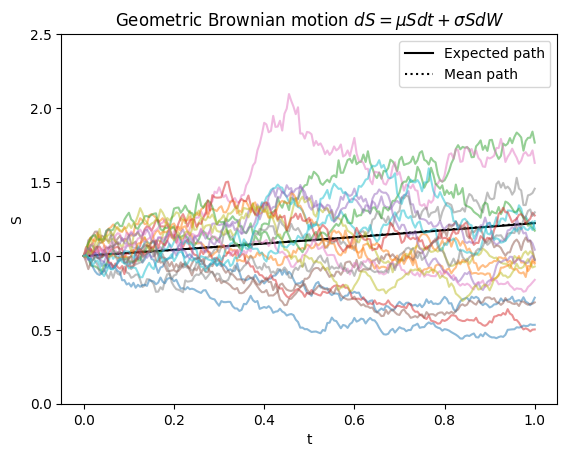

In [36]:
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(S, axis=0), ':k', label='Mean path')
plt.plot(t, S[::1000].T, alpha=0.5)  # Plot a subset of paths
plt.legend()
plt.xlabel('t')
plt.ylabel('S')
plt.ylim([0, 2.5])
plt.title(r'Geometric Brownian motion $dS = \mu S dt + \sigma S dW$')


Text(0.5, 1.0, 'Geometric Brownian motion: PDF at different times')

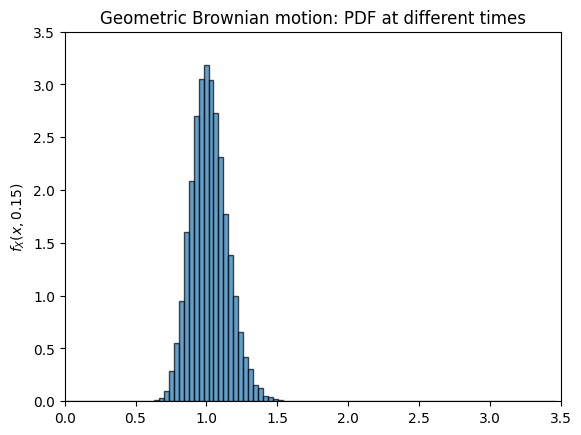

In [32]:

# Histogram at time step 20 (t ≈ 0.15)


plt.hist(S[:, 20], bins=np.arange(0, 3.5, 0.035), density=True, edgecolor='k', alpha=0.7)
plt.ylabel(r'$f_X(x,0.15)$')
plt.xlim([0, 3.5])
plt.ylim([0, 3.5])
plt.title('Geometric Brownian motion: PDF at different times')

(0.0, 3.5)

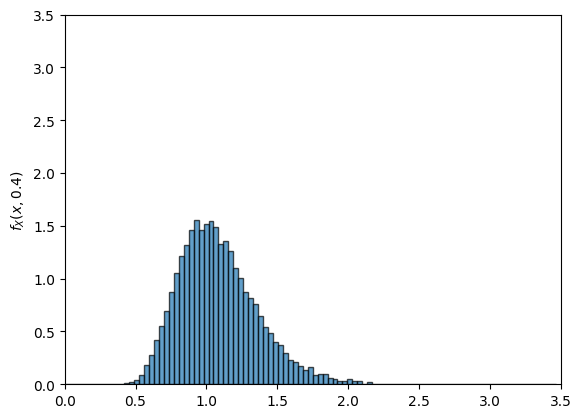

In [33]:
# Histogram at time step 80 (t ≈ 0.4)

plt.hist(S[:, 80], bins=np.arange(0, 3.5, 0.035), density=True, edgecolor='k', alpha=0.7)
plt.ylabel(r'$f_X(x,0.4)$')
plt.xlim([0, 3.5])
plt.ylim([0, 3.5])

(0.0, 3.5)

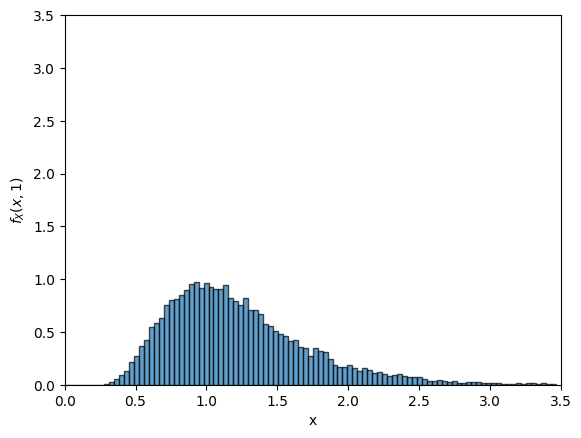

In [34]:
# Histogram at final time step (t = T)

plt.hist(S[:, -1], bins=np.arange(0, 3.5, 0.035), density=True, edgecolor='k', alpha=0.7)
plt.xlabel('x')
plt.ylabel(r'$f_X(x,1)$')
plt.xlim([0, 3.5])
plt.ylim([0, 3.5])